# Raw data EDA (before cleaning)
2026 Joey Manani & Anchorfish Team

Looks at the raw dataset file **before** cleaning

A big gap between features is **not** on its own a reason to drop something. A good feature is supposed to differ between type. 

Let's give them named (these are invented here, not actual terms):
1. **Same-site test:** is the feature present on the same site with and without the feature? Clean it out of the URL.
2. **Reality test:** is the rate believable for real traffic? Is it a reasonable value (human judgment)
3. **Research test:** is it consistent with actual research?

We will explain more these tests in the report, but same-site is quite important to understand, so I'll (Joey) provide a brief description:

Basically speaking, will the feature change depending on HOW the URL was actually stored? i.e from the set, is "http://www.phishingurl.com/" technically "worse" (phishing score) than "phishingurl.com"? These ARE the same site, so the feature should not be influenced by the way it's formatted in the URL.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

import style  # shared colours and chart look, see style.py

style.use()

############## SEE README ################
FINAL_TREE = Path("datasets/Final Tree")
EXTRA = Path("datasets/Extra Data")
##########################################
DATA = FINAL_TREE / "1 Raw Data - Run These Through Cleaning Scripts" / "malicious_phish.csv"  # provided Kaggle set
FIGURES = Path("figures")
FIGURES.mkdir(exist_ok=True)

SCHEME = r"^[a-zA-Z][a-zA-Z0-9+.-]*://"  # http://, https://

df = pd.read_csv(DATA)
# same names as the cleaned data (benign -> Legitimate), in a fixed order so every chart and table lines up
df["type"] = pd.Categorical(df.type.map(style.KAGGLE_NAMES), categories=style.TYPE_ORDER)
df.type.value_counts()

type
Legitimate    428103
Defacement     96457
Phishing       94111
Malware        32520
Name: count, dtype: int64

## 0. Quick health check
The Week 6 lecture's "five commands": look at a few rows, the column types, missing values, exact duplicates and a summary, first.

In [2]:
print(df.head(3), "\n")
print(df.dtypes, "\n")
print("missing values:", df.isnull().sum().sum())
print("exact duplicate rows:", df.duplicated().sum())  # broken down by type in section 4
df.describe()  # for text columns: how many, how many different, the most common value

                                   url        type
0                     br-icloud.com.br    Phishing
1  mp3raid.com/music/krizz_kaliko.html  Legitimate
2      bopsecrets.org/rexroth/cr/1.htm  Legitimate 

url          str
type    category
dtype: object 

missing values: 0
exact duplicate rows: 10066


,url,type
count,651191,651191
unique,641119,4
top,http://style.org.hc360.com/css/detail/mysite/s...,Legitimate
freq,180,428103


## 1. URL formatting by type
Shown as **% of each type**, not numbers: there are about 5x more legit URLs so we gotta scale them accordingly.

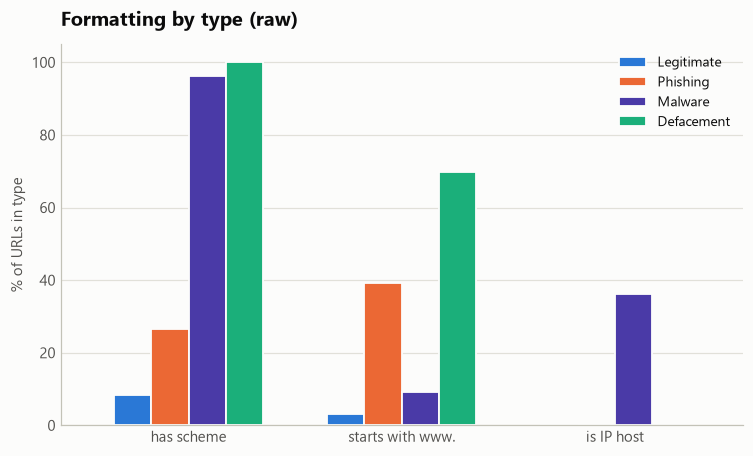

,has scheme,starts with www.,is IP host
type,,,
Legitimate,8.26,3.23,0.01
Phishing,26.41,39.10,0.35
Malware,96.28,9.31,36.20
Defacement,100.00,69.80,0.00


In [3]:
bare = df.url.str.replace(SCHEME, "", regex=True)  # so "http://www.x.com" still counts as starting with www


flags = pd.DataFrame({
    "type": df.type,
    "has scheme": df.url.str.match(SCHEME),
    "starts with www.": bare.str.match(r"(?i)www\d*\."),
    "is IP host": bare.str.match(r"(\d{1,3}\.){3}\d{1,3}"), # ipv4
})

# based on the flags, calculate percentages of the totals that have these features, and group these by their URL type
percentage_table = flags.groupby("type").mean() * 100

# must be transposed for plotting (one group per flag, one bar per type)
ax = percentage_table.T.plot.bar(rot=0, width=0.7, color=style.colours(percentage_table.index),
                                 ylabel="% of URLs in type", title="Formatting by type (raw)")
ax.legend(title=None)
ax.grid(False, axis="x")  # pandas turns on both grids, keep only the value axis
style.save(ax.figure, FIGURES / "raw_flags_by_type.png")
plt.show()
percentage_table.round(2)

So according to the output above, only 8% of the benigns have a scheme, compared to 26% of the phishing URLs. A model would treat the scheme as a strong indicator of malicious, but to me, a human, this is unreliable: every real URL has a scheme, so 8% says more about how the benign list was stored than about the sites themselves (reality test). The scheme gets stripped during cleaning.

The same pattern is observed for the other feature including whether it starts with www. 39% of phishing URLs start with www. compared to only 3% of the benigns, meaning a trained model will pick up that anything with www probably means phishing. This fails the same-site test (`www.x.com` is the same site as `x.com`) and the reality test, so instead of down-weighting it we clean www. out of every URL before extracting features. Just dropping the `has_www` column isn't enough, because www. also adds a dot and dot_count would pick it up.

IP host is interesting. 0.01% of the benigns are an IPv4 host compared to 0.35% of the phishing. This makes sense as a human since most real actual websites have a proper domain instead of just an IP. Malware is even better, where 36% of them are IP-based hosts which makes sense since purchasing a domain 1. costs money, 2. has an ownership record to make it traceable, 3. has to wait for DNS propagation to even work (>1 day)

> **Update (section 7):** most of that 39% came from a block of legit URLs that are labelled phishing. Flipped back, it's 21% of phishing vs 7% of legit. That's still a gap, so www still gets stripped, but about half of it was the mislabelling.

### 1b. A few more formatting flags
Same idea as above with four more: is it https, does it end with a `/`, does it have a `?query`, and does it have any uppercase letters.

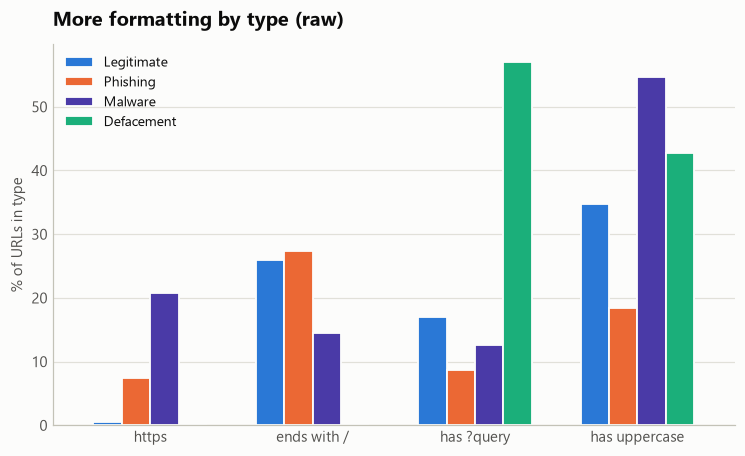

,https,ends with /,has ?query,has uppercase
type,,,,
Legitimate,0.46,25.98,17.02,34.66
Phishing,7.40,27.36,8.73,18.37
Malware,20.80,14.48,12.68,54.67
Defacement,0.00,0.00,56.98,42.80


In [4]:
more_flags = pd.DataFrame({
    "type": df.type,
    "https": df.url.str.match(r"(?i)https://"),
    "ends with /": df.url.str.endswith("/"),
    "has ?query": df.url.str.contains("?", regex=False),
    "has uppercase": df.url.str.contains("[A-Z]"),
})

more_percentage_table = more_flags.groupby("type").mean() * 100

ax = more_percentage_table.T.plot.bar(rot=0, width=0.7, color=style.colours(more_percentage_table.index),
                                      ylabel="% of URLs in type", title="More formatting by type (raw)")
ax.legend(title=None)
ax.grid(False, axis="x")
style.save(ax.figure, FIGURES / "raw_flags_more_by_type.png")
plt.show()
more_percentage_table.round(2)

Defacement is the odd one out here. From the first chart 100% of them have a scheme, but 0% are https and 0% end with a `/`. It appears that defacement URLs all were sourced from one place that stored them one specific way. This fails the same-site test: a model would learn how that source formats its URLs not anything about defacement. (Irrelevant to phishing but still important to understand and see here)

https is backwards too. Only 0.46% of the benigns are https, compared to 20.8% of malware and 7.4% of phishing. About 92% of the benigns have no scheme at all, so they cannot be https in the first place. A model trained on this would learn https = bad, which fails the reality test. So https has the same problem as scheme and www. (https *is* a scheme, makes sense anyways)

Query and uppercase differ a lot as well (57% of defacement has a query, 55% of malware has uppercase vs 18% of phishing). These are more about the page than about how the URL got written down, so a gap here is interesting but not necessarily a problem. Often times, these URLs have URL encodings which *are* uppercase by design, so while its not immediately bad data, its still a convention that cannot reasonably differentiate between the different URL types since both legit and malicious sites use uppercase characters for encoding. The sake is, *does it have encoding* in the first place?

## 2. URL length, legit vs phishing

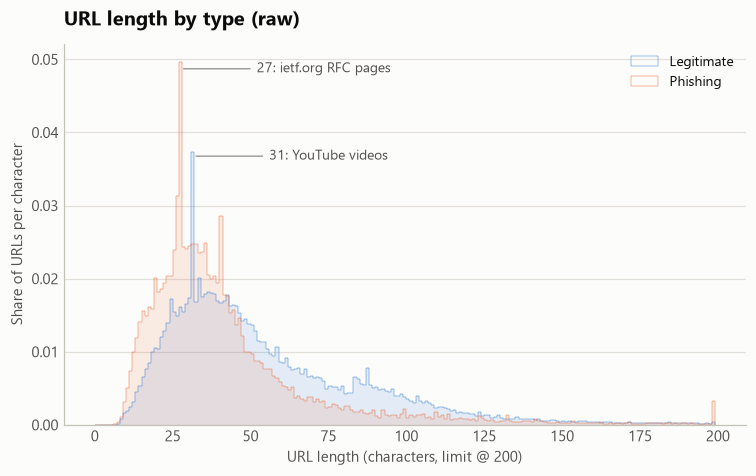

type
Legitimate    46.0
Phishing      35.0
Malware       49.0
Defacement    81.0
Name: url, dtype: float64

In [5]:
length = df.url.str.len()
LENGTH = range(0, 200, 1)

fig, ax = plt.subplots()
for url_type in ["Legitimate", "Phishing"]: # do this for the legits and phishing urls; create a histogram with outline
    colour = style.TYPE_COLOURS[url_type]
    lengths = length[df.type == url_type]

    # density, not number of again
    ax.hist(lengths, bins=LENGTH, density=True, histtype="stepfilled", color=colour, alpha=0.12, edgecolor="none")  # light wash
    ax.hist(lengths, bins=LENGTH, density=True, histtype="step", color=colour, linewidth=0.3, label=url_type)  # outline

# label the two spikes explained further down (section 2 notes and section 5)
for url_type, spike, text in [("Legitimate", 31, "31: YouTube videos"), ("Phishing", 27, "27: ietf.org RFC pages")]:
    height = (length[df.type == url_type] == spike).mean()
    ax.annotate(text, xy=(spike + 0.5, height), xytext=(spike + 25, height), color=style.INK_SOFT, fontsize=9,
                va="center", arrowprops={"arrowstyle": "-", "color": style.MUTED, "linewidth": 0.8})

ax.set_xlabel("URL length (characters, limit @ 200)")
ax.set_ylabel("Share of URLs per character")
ax.set_title("URL length by type (raw)")
ax.legend()
style.save(fig, FIGURES / "raw_length_by_type.png")
plt.show()
length.groupby(df.type).median()

### Certain things to play with

- Can set the upper value to 500, but above 200 is mostly outliers. 200 is fine, step = 1. This shows a pretty wide distribution of the URL lengths and is cool to see most is within a certain range.
- If set density to False, look at the massive spike at 31 (benign), over half of it (8,545 of 15,737) is legitimate YouTube URLs. Nearly all of those are video links: `youtube.com/watch?v=` plus the 11 character video ID is exactly 31 characters. Cool
- The same large spike at phishing url's 27 length looked like genuine random phishing bunching at 27... Wow. Turns out it isn't: section 5 shows it's one mislabelled site.

### Interestingly...

So according to this set of data, actually, the PHISHING URLs are shorter than the benign ones. This seems counterintuitive at first glance, but it could be due to the way the dataset was created. This is really interesting to know, and will therefore mean that URL length could be a useful feature for distinguishing between benign and phishing URLs - but we need to be careful not to overfit to this single feature since clearly the counterintuitiveness means it could be either way. This histogram revealed a lot actually. (I, Joey, also played a significant amount using Excel's inbuilt sort and filter functions - we need to do this programmatically as well, therefore this notebook exists)

> **Update (section 7):** this was mostly the swapped blocks. Once they're flipped back, phishing (median 47) is **longer** than legit (42), which matches feasibility. Good thing.

### 2b. Length outliers, all four types
The histogram above stops at 200 and only has benign and phishing, so the very long and very short URLs are hidden. A box plot on a log scale shows all four types. The whiskers are set to 1% and 99%, so every dot is in the most extreme 2% of its type.

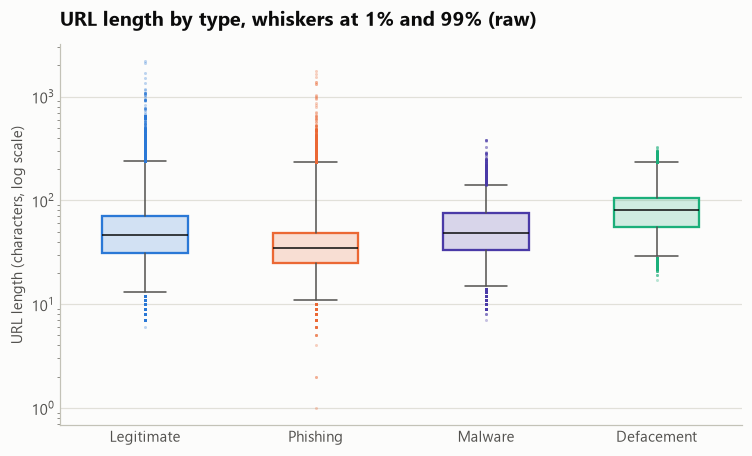

,count,mean,std,min,1%,50%,99%,max
type,,,,,,,,
Legitimate,428103.0,58.0,44.0,6.0,13.0,46.0,239.0,2175.0
Phishing,94111.0,46.0,44.0,1.0,11.0,35.0,234.0,1779.0
Malware,32520.0,57.0,28.0,7.0,15.0,49.0,141.0,378.0
Defacement,96457.0,86.0,42.0,17.0,29.0,81.0,235.0,327.0


In [6]:
fig, ax = plt.subplots()
boxes = ax.boxplot(
    [length[df.type == t] for t in style.TYPE_ORDER],
    tick_labels=style.TYPE_ORDER,
    whis=(1, 99),  # whisker cap at 1% and 99% (lower than 1% of data; higher than 99% of data are outlier)
    widths=0.5,
    patch_artist=True,
    whiskerprops={"color": style.INK_SOFT},
    capprops={"color": style.INK_SOFT},
    flierprops={"markersize": 2, "alpha": 0.3, "markeredgecolor": "none"},
)
for box, outliers, t in zip(boxes["boxes"], boxes["fliers"], style.TYPE_ORDER):
    box.set(facecolor=style.TYPE_COLOURS[t] + "33", edgecolor=style.TYPE_COLOURS[t], linewidth=1.5)
    outliers.set(markerfacecolor=style.TYPE_COLOURS[t])

ax.set_yscale("log")
ax.set_ylabel("URL length (characters, log scale)")
ax.set_title("URL length by type, whiskers at 1% and 99% (raw)")
style.save(fig, FIGURES / "raw_length_outliers_by_type.png")
plt.show()
length.groupby(df.type).describe(percentiles=[0.01, 0.5, 0.99]).round(0)

In [7]:
df[length <= 5]  # the shortest "URLs" in the whole set

,url,type
374391,1b.yt,Phishing
573423,¾5092,Phishing
573437,,Phishing
573446,½4+,Phishing
573449,=Â-,Phishing
573468,ºE,Phishing
573471,WY,Phishing
573485,)-,Phishing


Seems theres some malformed URLs in the dataset too... We will clean them later!


The boxes (the middle 50%) sit in a similar place for all four, so a normal URL is not wildly different between types. The tails are where it gets weird:

- Benign goes up to 2,175 characters and phishing to 1,779, while defacement and malware stop at 327 and 378.
- Phishing goes down to 1 character. The table above is every URL of 5 characters or less: all 8 are labelled phishing and most of them are broken bytes, not URLs. These need to be cleaned out.

The outliers are not many rows (99% of every type is under 240 characters).

> **Update (section 7):** 7 of those 8 sit are in rows 573,423 - 573,485, inside a patch of 92 broken rows in the middle of one of the swapped blocks. The 8th (`1b.yt`) is a real short link. The cleaning script now drops the junk.

## 3. Top TLDs by type
In `eda_features.ipynb`, because `tld` column only exists in the extracted features.

## 4. Duplicates and conflicting labels
How many rows are an exact copy of an earlier row (same URL and same type), as **% of each type**.

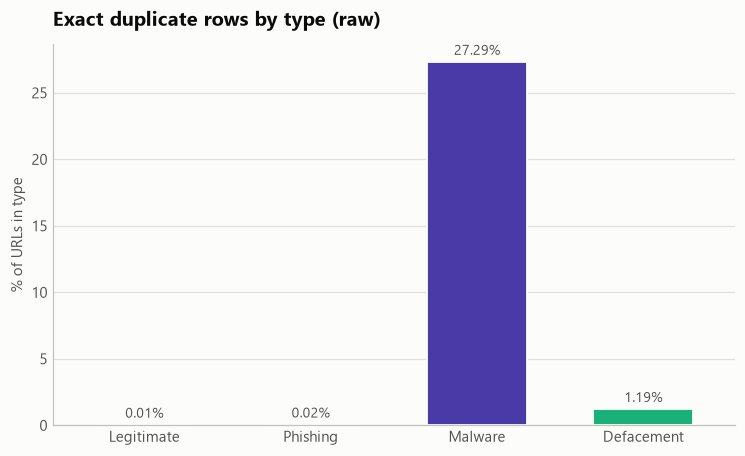

,duplicate rows,% of type
type,,
Legitimate,23,0.01
Phishing,19,0.02
Malware,8875,27.29
Defacement,1149,1.19


In [8]:
is_duplicate = df.duplicated()  # same url AND same type as an earlier row

duplicate_table = pd.DataFrame({
    "duplicate rows": is_duplicate.groupby(df.type).sum(),
    "% of type": is_duplicate.groupby(df.type).mean() * 100,
})

ax = duplicate_table["% of type"].plot.bar(rot=0, xlabel="", width=0.6, color=style.colours(duplicate_table.index),
                                           ylabel="% of URLs in type", title="Exact duplicate rows by type (raw)")

ax.grid(False, axis="x")
ax.bar_label(ax.containers[0], fmt="%.2f%%", padding=3, color=style.INK_SOFT, fontsize=9)
style.save(ax.figure, FIGURES / "raw_duplicates_by_type.png")
plt.show()
duplicate_table.round(2)

In [9]:
# same URL, but labelled as two different types (12) not many to filter
labels_per_url = df.groupby("url").type.nunique()
df[df.url.isin(labels_per_url[labels_per_url > 1].index)].sort_values("url")

,url,type
328665,ebookstore.sony.com/reader/,Legitimate
616942,ebookstore.sony.com/reader/,Phishing
259609,en.wikipedia.org/wiki/Desktop_publishing,Legitimate
616832,en.wikipedia.org/wiki/Desktop_publishing,Phishing
213051,en.wikipedia.org/wiki/E-book,Legitimate
616866,en.wikipedia.org/wiki/E-book,Phishing
275788,groups.yahoo.com/group/Band-in-a-Box/,Legitimate
625973,groups.yahoo.com/group/Band-in-a-Box/,Phishing
181226,memory.loc.gov/ammem/ccmphtml/colahome.html,Legitimate
609889,memory.loc.gov/ammem/ccmphtml/colahome.html,Phishing


10,066 rows are exact copies, and 8,875 of those are malware. That is 27% of the malware, compared to 0.01% of the benigns. So malware is really about 23,600 different URLs and not 32,520, and it was already the smallest type.

If the copies stay in, the same URL can land in both the training set and the test set, and the score will look better than it really is. They need to go before any split.

The second table is the 6 URLs that are in the set twice with two different labels, benign and phishing every time. It's only 12 rows, but a Wikipedia article cannot be both. More on this in section 6.

## 5. How many URLs is each host?
650k URLs is not 650k websites. Here the host is pulled out of each URL (everything before the first `/`, lowercased, without the `www.`) to see how many different sites each type is made of.

Hypothesis: some hosts will be packed with a bunch of URLs from the same type

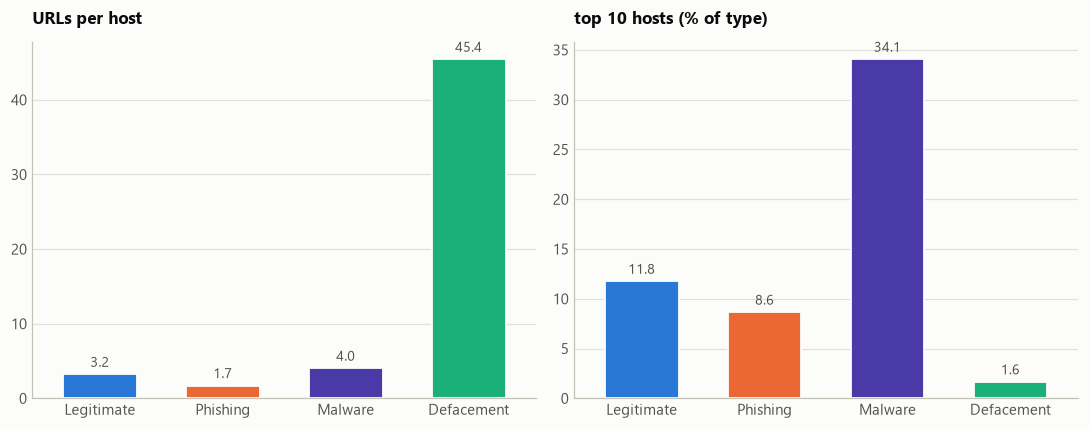

In [10]:
host = (bare.str.split(r"[/?#]", n=1, regex=True).str[0].str.lower().str.replace(r"^www\d*\.", "", regex=True))

by_type = host.groupby(df.type)
concentration = pd.DataFrame({
    "URLs per host": by_type.size() / by_type.nunique(),
    "top 10 hosts (% of type)": by_type.apply(lambda h: h.value_counts(normalize=True).head(10).sum() * 100),
})

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, column in zip(axes, concentration.columns):
    concentration[column].plot.bar(ax=ax, rot=0, xlabel="", width=0.6, color=style.colours(concentration.index))
    ax.set_title(column, fontsize=11)
    ax.grid(False, axis="x")
    ax.bar_label(ax.containers[0], fmt="%.1f", padding=3, color=style.INK_SOFT, fontsize=9)

fig.tight_layout()
style.save(fig, FIGURES / "raw_host_concentration.png")
plt.show()

In [11]:
# Table: rank x type, each cell "host (pct of type%)"
pd.DataFrame(
    {t: [f"{h} ({v:.2f}%)" for h, v in host[df.type == t].value_counts(normalize=True).mul(100).head(5).items()] for t in style.TYPE_ORDER},
    index=range(1, 6),
).rename_axis("rank")

,Legitimate,Phishing,Malware,Defacement
rank,,,,
1,en.wikipedia.org (2.96%),tools.ietf.org (3.39%),9779.info (12.25%),allaroundrental.com (0.27%)
2,youtube.com (2.01%),angelfire.com (1.39%),mitsui-jyuku.mixh.jp (8.85%),bruynzeelmultipanel.be (0.23%)
3,facebook.com (1.81%),pastehtml.com (1.00%),apbfiber.com (3.53%),ninopizzaria.com.br (0.22%)
4,amazon.com (1.08%),en.wikipedia.org (0.57%),pastebin.com (3.04%),tandemimmobilier.fr (0.20%)
5,imdb.com (0.81%),sourceforge.net (0.57%),toulousa.com (1.54%),zibae.ir (0.19%)


Defacement is 96,457 URLs from only 2,123 hosts, so about 45 URLs per site. Phishing is the opposite at 1.7. With a random train/test split, pages from the same defaced site end up on both sides and the model only needs to remember the site. The host COULD be split into different sets...

Malware's top 10 hosts are 34% of it, and just two of them (`9779.info` and `mitsui-jyuku.mixh.jp`) are 21%. Whatever those two sites look like is what the model will think malware looks like. Overfitting....

The phishing column fails the reality test. The biggest "phishing" host is `tools.ietf.org` at 3.4%, which is where the internet standards (RFCs) are published, and Wikipedia is 4th. There's a bit from `sourceforge.net` too, but not as much. 

This also explains the spike at length 27 in section 2. Example: `tools.ietf.org/html/rfc1951` is 27 characters, and 2,333 of the 4,584 phishing URLs with length 27 are from IETF. Without them, 27 is the same height as its neighbours (smoother bell curve). So that spike is not phishing bunching up, it is one mislabelled site from the data set.

> **Update (section 7):** found out why. Every IETF row is in one block at the end of the file whose labels are swapped.

## 6. Hosts with more than one label
Following on from the 6 conflicting URLs: a whole host can be under more than one type too. These are the 15 hosts with the most URLs that disagree with the host's main label.

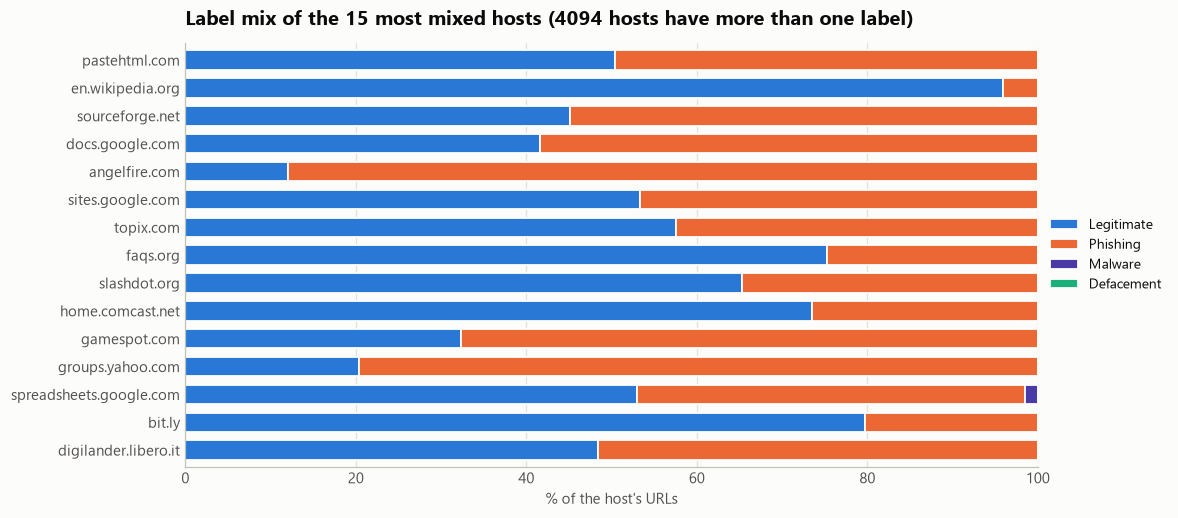

type,Legitimate,Phishing,Malware,Defacement
url,,,,
pastehtml.com,960,944,0,0
en.wikipedia.org,12668,538,0,0
sourceforge.net,441,536,0,0
docs.google.com,197,276,0,0
angelfire.com,179,1306,0,0
sites.google.com,145,127,0,0
topix.com,171,126,0,0
faqs.org,258,85,0,0
slashdot.org,154,82,0,0


In [12]:
label_mix = pd.crosstab(host, df.type)
mixed = label_mix[(label_mix > 0).sum(axis=1) > 1]  # hosts that are under more than one type
disagree = mixed.sum(axis=1) - mixed.max(axis=1)  # URLs that are not the host's main label
worst = mixed.loc[disagree.nlargest(15).index]

# each host as 100%, [::-1] so the worst one is at the top
ax = worst.div(worst.sum(axis=1), axis=0).mul(100).iloc[::-1].plot.barh(
    stacked=True, figsize=(10, 5), width=0.7, color=style.colours(worst.columns), xlabel="% of the host's URLs", ylabel="",
    title=f"Label mix of the 15 most mixed hosts ({len(mixed)} hosts have more than one label)",
)

ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
style.save(ax.figure, FIGURES / "raw_mixed_label_hosts.png")
plt.show()
worst

4,094 hosts are under more than one type, and the top 15 are pretty much all benign vs phishing.

`pastehtml.com`, `docs.google.com`, `sites.google.com`, `angelfire.com` and `bit.ly` let anyone put up anything, so these hosts have both good and bad pages. Therefore, the host tells the model nothing and it has to come from the rest of the URL.

Some of it is not believable. `en.wikipedia.org` has 538 phishing URLs and `sourceforge.net` is more phishing (536) than benign (441). Together with `tools.ietf.org` in section 5, it looks like part of the phishing set is mislabelled benign pages. We have a LOT of cleaning to do!

> **Update (section 7):** turns out it's mostly one problem, not lots of them: two swapped blocks. Flipped back, only 53 hosts are both legit and phishing instead of 4,061.

## 7. Where in the file are the mislabels?
This looks at **where the mislabels sit in the file**. If the file was shuffled properly, every type should be spread evenly from the top to the bottom. There are lots of runs at the end of the file indicating a paste.

### 7a. Data Shuffling

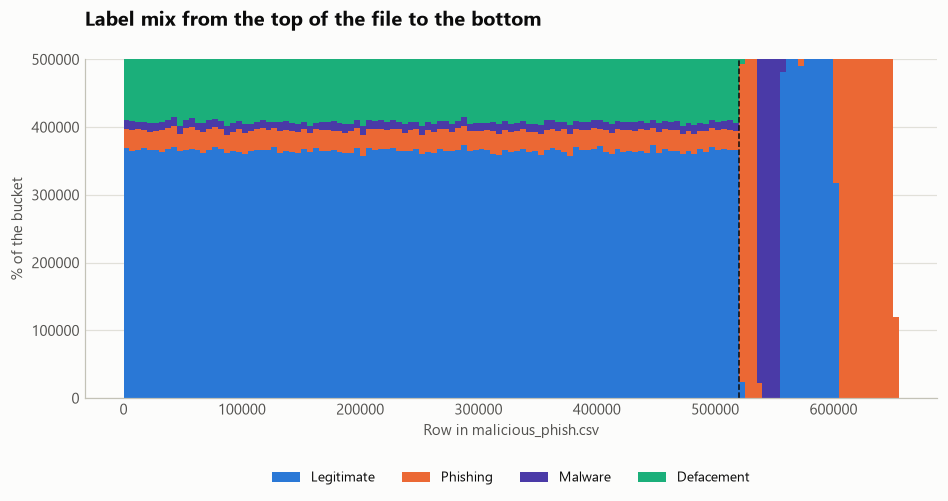

,type,first_row,last_row,rows
0,Phishing,520330,535218,14889
1,Malware,535219,555185,19967
2,Legitimate,555186,573416,18231
3,Legitimate,573511,603181,29671
4,Phishing,603182,651190,48009


In [13]:
# a "run" is a stretch of rows with the same label. a new one starts every time the label changes
run_id = df.type.ne(df.type.shift()).cumsum()
runs = (pd.DataFrame({"type": df.type, "row": df.index}).groupby(run_id)
        .agg(type=("type", "first"), first_row=("row", "min"), last_row=("row", "max"), rows=("row", "size")))

# label mix of every 5000 rows, top of the file on the left
BUCKET = 5_000

mix = pd.crosstab(df.index // BUCKET * BUCKET, df.type) * 100

fig, ax = plt.subplots(figsize=(10, 4))
bottom = 0
for t in style.TYPE_ORDER:
    ax.bar(mix.index, mix[t], bottom=bottom, width=BUCKET, align="edge", color=style.TYPE_COLOURS[t], linewidth=0, label=t)
    bottom = bottom + mix[t]
    
# ===== segment =====
    
# add line at 520330 which is where the mislabelling starts and shuffling ends.
ax.axvline(520_330, color=style.INK, linewidth=1, linestyle="--")

ax.set_xlabel("Row in malicious_phish.csv")
ax.set_ylabel("% of the bucket")
ax.set_title("Label mix from the top of the file to the bottom", pad=22)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=4)
style.save(fig, FIGURES / "raw_labels_by_row.png")
plt.show()

runs[runs.rows >= 2_000].reset_index(drop=True)  # every run of 2,000+ rows (a shuffled file never gets close)

### 7b. Data Shuffling continued

It isn't shuffled all the way down. The first 520,330 rows are true scrambled, but after that, categories were just pasted on as its own block: 14,889 phishing, 19,967 malware, about 48,000 benign (split in two by the 92 broken rows as per section 2b), then 48,009 phishing to the very end.

Victor Le Pochat, Tom Van Goethem, Samaneh Tajalizadehkhoob, Maciej Korczyński, and Wouter Joosen. 2019. "Tranco: A Research-Oriented Top Sites Ranking Hardened Against Manipulation," Proceedings of the 26th Annual Network and Distributed System Security Symposium (NDSS 2019). https://doi.org/10.14722/ndss.2019.23386 

https://tranco-list.eu/list/94GG2/1000000

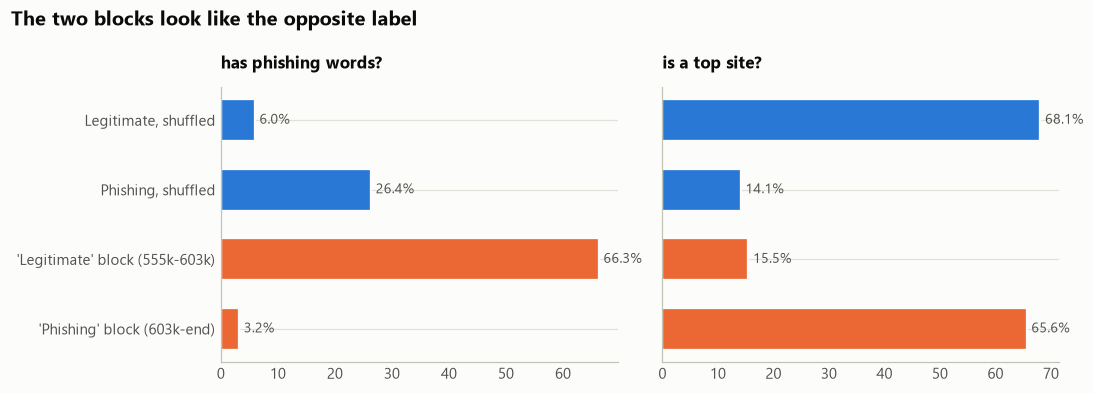

,rows,has scheme %,starts www. %,median length,phishing words %,top site %
"Legitimate, shuffled",380199.0,9.3,0.0,44.0,6.0,68.1
"Phishing, shuffled",31121.0,32.0,13.6,25.0,26.4,14.1
'Legitimate' block (555k-603k),47904.0,0.0,28.6,67.0,66.3,15.5
'Phishing' block (603k-end),48009.0,0.0,63.4,34.0,3.2,65.6


In [14]:
TOP_SITES = EXTRA / "tranco-1m.csv"  # Tranco list of the most visited sites (rank, domain)
top_sites = set(pd.read_csv(TOP_SITES, header=None, names=["rank", "domain"]).domain)


def on_top_site(h):
    """True if the host is a top site or a subdomain of one (login.microsoft.com -> microsoft.com)."""
    labels = h.split(".")
    return any(".".join(labels[i:]) in top_sites for i in range(len(labels) - 1))


# words phishing URLs use a lot, merged with Luke's sensitive word list from feature extractions
SENSITIVE_WORDS = r"(?i)login|log-in|autologin|signin|sign-in|verif|verify|verification|account|secure|security|update|webscr|paypal|ebay|bank|banking|confirm|password|credentials|billing|authentication|authenticate|wallet|payment|wp-|\.php"



# block index caps
SHUFFLED = df.index < 520_330
BENIGN_BLOCK = (df.index >= 555_186) & (df.index <= 603_181)
PHISHING_BLOCK = df.index >= 603_182

segments = {
    "Legitimate, shuffled": SHUFFLED & df.type.eq("Legitimate"),
    "Phishing, shuffled": SHUFFLED & df.type.eq("Phishing"),
    "'Legitimate' block (555k-603k)": BENIGN_BLOCK & df.type.eq("Legitimate"),
    "'Phishing' block (603k-end)": PHISHING_BLOCK,
}

blocks = pd.DataFrame({name: {
    "rows": rows.sum(),
    "has scheme %": df.url[rows].str.match(SCHEME).mean() * 100,
    "starts www. %": bare[rows].str.match(r"(?i)www\d*\.").mean() * 100,
    "median length": bare[rows].str.len().median(),
    "phishing words %": df.url[rows].str.contains(SENSITIVE_WORDS).mean() * 100,
    "top site %": host[rows].map(on_top_site).mean() * 100,
} for name, rows in segments.items()}).T

labelled_as = ["Legitimate", "Legitimate", "Phishing", "Phishing"]  # the label each segment has in the file


fig, axes = plt.subplots(1, 2, figsize=(10, 3.6), sharey=True)

rows = blocks[::-1] # reverse them

types = labelled_as[::-1]
edges = [style.TYPE_COLOURS[t] for t in types]
fills = [c for c in edges]

COLMAP = {
    "phishing words %": "has phishing words?",
    "top site %": "is a top site?"
}

for ax, column in zip(axes, ["phishing words %", "top site %"]): # just visualise these two cols for now
    bars = ax.barh(rows.index, rows[column], color=fills, height=0.6, linewidth=1.5)
    ax.bar_label(bars, fmt="%.1f%%", padding=3, color=style.INK_SOFT, fontsize=9)
    ax.set_title(COLMAP.get(column), fontsize=11)


fig.suptitle("The two blocks look like the opposite label", x=0.01, ha="left", fontweight="bold", fontsize=13)
fig.tight_layout()
style.save(fig, FIGURES / "raw_swapped_blocks.png")
plt.show()

blocks.round(1)

In [15]:
is_phishing = df.type.eq("Phishing")

RANDOM_STATE = 987654321

for site in ["ietf.org", "wikipedia.org", "sourceforge.net", "ibm.com", "w3.org", "youtube.com"]: # trusted domains
    on_site = host.eq(site) | host.str.endswith("." + site)   # site or any subdomain
    
    total = (on_site & is_phishing).sum() # total number of phishing rows for this trusted site
    in_block = (on_site & is_phishing & PHISHING_BLOCK).sum() # is it actually in the hypothesised mislabelled 'Phishing' block?
    print(f"{site}: {total} phishing rows, {in_block} in the 'Phishing' block; {in_block/total*100:.1f}%")

# eyeball test. as a human, are these BOTH phishing? the mislabelled 'legitimate' one is probably phishing
compare = ["Phishing, shuffled", "'Legitimate' block (555k-603k)"]
pd.DataFrame({
    name: df.url[segments[name]].sample(8, random_state=RANDOM_STATE).str[:70].to_numpy() for name in compare
})

ietf.org: 3212 phishing rows, 3212 in the 'Phishing' block; 100.0%
wikipedia.org: 550 phishing rows, 550 in the 'Phishing' block; 100.0%
sourceforge.net: 713 phishing rows, 712 in the 'Phishing' block; 99.9%
ibm.com: 337 phishing rows, 337 in the 'Phishing' block; 100.0%
w3.org: 193 phishing rows, 193 in the 'Phishing' block; 100.0%
youtube.com: 7 phishing rows, 6 in the 'Phishing' block; 85.7%


,"Phishing, shuffled",'Legitimate' block (555k-603k)
0,mysuccessplanet.com,ps3pool.com.br/promocaopremiada/system/seguran...
1,bireysel.ziraatwebgirisleri.com,txellwebs.com/blog/wp-content/scap/0f3b500cdb2...
2,http://regalifurnihcecrdt.blogspot.com/,www.comprapremiada.info
3,paypal.kunden00xkonten00x00x1600-verifikations...,paypal-com.us.webscrlcmdl.login.submit.dispatc...
4,wp.twells.com.hostingmurah.co,pastehtml.com/view/bejvpuc2r.html
5,radiofamaperu.com,paypal.com.us.cgi-bin.webscr.cmd-login.activat...
6,ziraatbankasi-giris.com,docs.google.com/spreadsheet/viewform?pli=1&amp...
7,keecompany.com,www.feelingsflowers.com/img/retail.santander.c...


Wow... They look like the opposite label:

(The chart sisters above can be analysed visually in an "X" pattern: top-left = bottom-right; bottom-left = top-right)

- The "Legitimate" block has phishing words in 66% of its URLs (real legit: 5.9%) and is almost never a popular site (4.2%). PayPal `webscr` kits, `wp-content/.../login`, actual phishing dodgy links
- The "Phishing" block has phishing words in only 2.8% and is a top site 37.9% of the time, uncannily close as real legit (37.6%). w3, gnu, wikipedia, ietf.
- **Every** IETF, Wikipedia, ibm.com and w3.org "phishing" row is in that last block. The mislabel "fixer" in the cleaning script was only catching the obvious cases here. (1 youtube link is elsewhere - can reasonably let it slide (for now)...)

**Decision:** `process_datasets.py` (feature-extraction repo) flips the two blocks back by static row position: rows 555,186-603,181 become Phishing and rows 603,182 to the end become Legitimate. It won't run on any file that isn't 651,191 rows, since the positions only fit the Kaggle set

### 7c. URLs were stored differently here
While checking the blocks, some URLs are wrapped in quotes (`'site.com/a'`), with every `%` written as `\%`, and some have `&` copied out of a web page as `&amp;`. This is a canonicalisation issue that needs to be addressed.

These fail the same-site test: `'site.com/a?x=1&amp;y=2'` is the same page as `site.com/a?x=1&y=2`, but the quotes and escapes add length and symbols that a model would pick up. The quotes also stopped www stripping from working (became `'www`).

**Decision:** `canonical_url` now has to remove the wrapping quotes, turns `\%` back into `%` and `&amp;` back into `&`. Only `&amp;` is replaced on purpose, because a traditional "un-HTML" function would also turn a real query like `&copy=2` into `©=2` because that's how it's designed to work.


### 7d. What changes once the blocks are flipped back
The same numbers as sections 1, 2 and 6, with the labels as they are in the file vs with the two blocks flipped back (exactly what the cleaning script now does). Length here is without the scheme

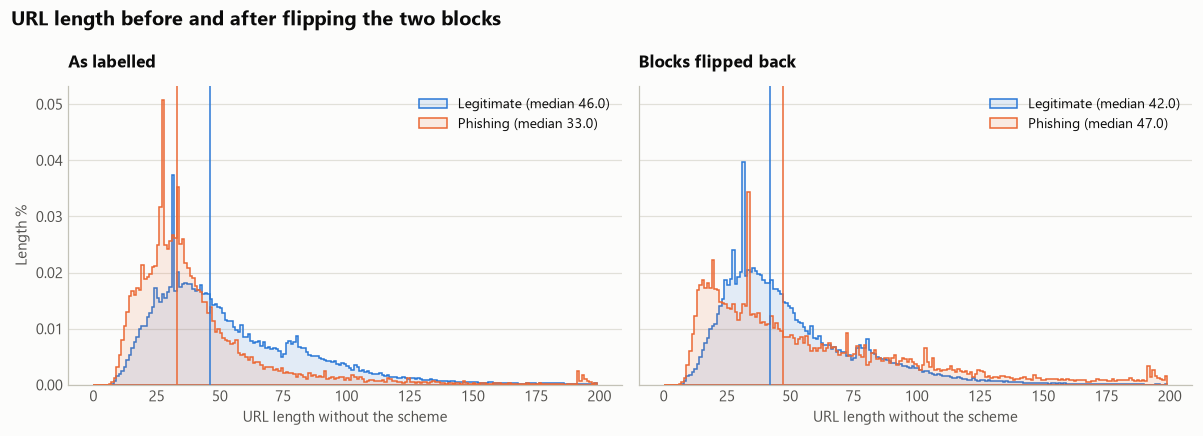

,As labelled,Blocks flipped back
Legitimate: starts www. %,3.2,7.1
Legitimate: median length,46.0,42.0
Phishing: starts www. %,39.1,21.3
Phishing: median length,33.0,47.0


In [16]:
from matplotlib.colors import to_rgba

# === SEGMENT ===

# Undo the label swap now
fixed = df.type.copy()
fixed[BENIGN_BLOCK & df.type.eq("Legitimate")] = "Phishing"  # leave the 92 rows already labelled Phishing alone
fixed[PHISHING_BLOCK] = "Legitimate"

# === SEGMENT ===

versions = {"As labelled": df.type, "Blocks flipped back": fixed}
LABELS = ["Legitimate", "Phishing"]
starts_www = bare.str.match(r"(?i)www\d*\.")   # bare = URL without the scheme
url_length = bare.str.len()

# === SEGMENT ===

def summarise(types):
    """Returns the actual data we want to see to be plotted; just small abstraction to make things easier"""
    stats = {}
    for label in LABELS:
        is_label = types.eq(label)
        stats[f"{label}: starts www. %"] = starts_www[is_label].mean() * 100
        stats[f"{label}: median length"] = url_length[is_label].median()
    return stats

before_after = pd.DataFrame({name: summarise(types) for name, types in versions.items()}) # send both original and fixed set to summarise fn


# === SEGMENT ===

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, (title, types) in zip(axes, versions.items()):
    for label in LABELS:
        colour = style.TYPE_COLOURS[label]
        lengths = url_length[types.eq(label)]
        median = lengths.median() # 
        

        ax.hist(lengths, bins=range(0, 200), density=True, histtype="stepfilled",
                facecolor=to_rgba(colour, 0.12), edgecolor=colour, linewidth=1,
                label=f"{label} (median {median})")
        ax.axvline(median, color=colour, linewidth=1) # median line


    ax.set_title(title, fontsize=11)
    ax.set_xlabel("URL length without the scheme")
    ax.legend()

axes[0].set_ylabel("Length %")
fig.suptitle("URL length before and after flipping the two blocks", x=0.01, ha="left", fontweight="bold", fontsize=13)
fig.tight_layout()
style.save(fig, FIGURES / "raw_length_flipped.png")
plt.show()

before_after.round(1)

- **www:** 39% vs 3% becomes 21% vs 7%. Still a big gap in this set, so stripping www is still needed
- **Median Length:** phishing goes from shorter than legit (33 vs 46) to longer (47 vs 42). That's the direction expected. Length can be kept as a normal feature.